# TSPTW-D Benchmark
Evaluates the trained **GNN** on the TSPTW-D problem.

Objective:

$$Z(\sigma) = 	au_{	ext{return}} + \sum_i \lambda_i \cdot \max(0,\, 	au_i - b_i)$$

**Dynamic cost** $c_{ij}(t) = c_{ij}^{	ext{base}} \cdot (1 + \delta_{ij}(t))$

**Next-day rule** — arrival $> b_i 	imes (1 + 5\%)$ postpones delivery to
$	au_i \leftarrow H + a_i$ (next morning opening).

## 1. Configuration & Model Loading

In [20]:
import os, sys, time
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ── Device selection ──────────────────────────────────────────────────────────
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')

# ── Paths ─────────────────────────────────────────────────────────────────────
_HERE       = os.path.dirname(os.path.abspath('__file__'))
DATASET_DIR = os.path.join(_HERE, '..', '..', 'datasets')
FIGURES_DIR = Path(_HERE) / 'figures' / 'benchmark'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ── User config ───────────────────────────────────────────────────────────────
SIZE     = 'small'   # 'small' | 'medium' | 'large'
N_REPS   = 20        # timing repetitions per algorithm
LATE_TOL = 0.05      # 5 % tolerance before next-day rule applies

MODEL_PATH = os.path.join(_HERE, 'model', f'gnn_{SIZE}_tsptwd.pt')

print(f'Device : {DEVICE}')
print(f'Model  : {MODEL_PATH}')
print(f'Dataset: {DATASET_DIR}')


Device : mps
Model  : /Users/giacomoberetta/Development/projects/Personnal/CESI/rec_op/DL_MODEL/gnn/model/gnn_small_tsptwd.pt
Dataset: /Users/giacomoberetta/Development/projects/Personnal/CESI/rec_op/DL_MODEL/gnn/../../datasets


In [21]:
sys.path.insert(0, _HERE)
from model import TSPGNN, MODEL_SIZES

if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(f'{MODEL_PATH} not found — run train.py first.')

_ckpt     = torch.load(MODEL_PATH, map_location='cpu')
_node_dim = _ckpt['node_in.weight'].shape[1]
_edge_dim = _ckpt['edge_in.weight'].shape[1]

D, L  = MODEL_SIZES[SIZE]
model = TSPGNN(d=D, L=L, node_dim=_node_dim, edge_dim=_edge_dim)
model.load_state_dict(_ckpt)
model.to(DEVICE)
model.eval()

n_params = sum(p.numel() for p in model.parameters())
print(f'Loaded   : {SIZE}  ({n_params:,} parameters)')
print(f'node_dim : {_node_dim}   edge_dim: {_edge_dim}')
print(f'Device   : {next(model.parameters()).device}')


Loaded   : small  (85,893 parameters)
node_dim : 5   edge_dim: 2
Device   : mps:0


## 2. Model Performance & Details

Parameters : 85,893
Inference  : 0.818 ms  (±0.056)  on mps, n=10
Training   : 3000 steps   best loss 0.0382


<>:58: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
<>:58: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
/var/folders/88/l_yf60w979v14wzzbrzrq69r0000gp/T/ipykernel_26692/2403219233.py:58: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
  ax.set_title('Predicted probs $\hat{p}_{ij}$')


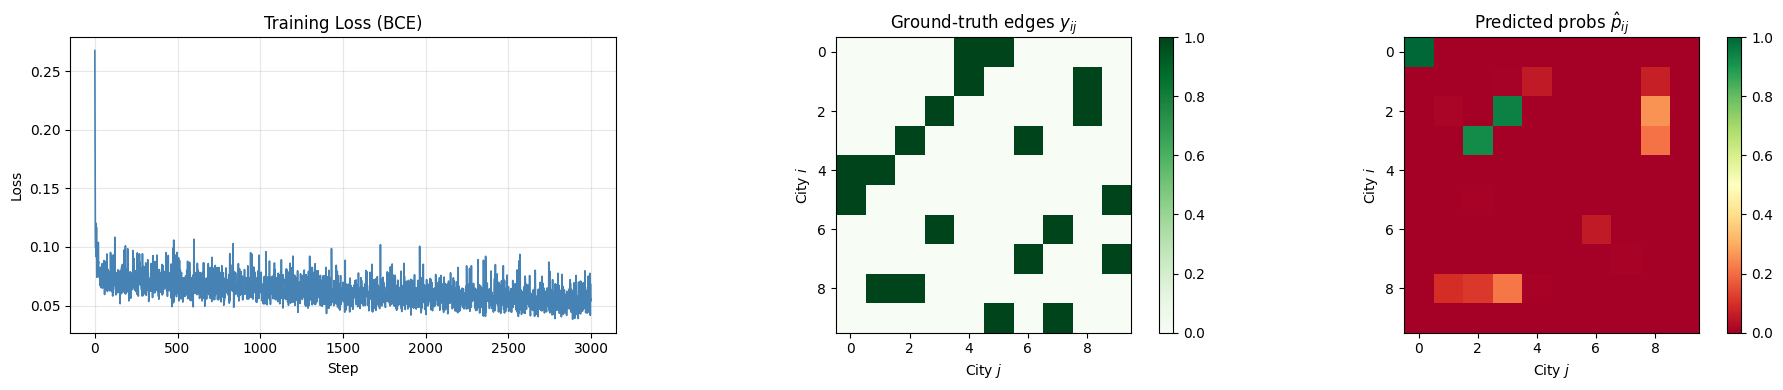

In [22]:
_loss_path = os.path.join(_HERE, 'model', 'losses.npy')
losses = np.load(_loss_path).tolist() if os.path.exists(_loss_path) else []

from data import (build_tsptwd_features, generate_time_windows,
                  generate_perturbations, optimal_tour_labels, greedy_decode)

# Probe instance for timing and visualisation
_coords_p = torch.rand(10, 2)
_tw_p, _svc_p = generate_time_windows(_coords_p, seed=0)
_perturbs_p   = generate_perturbations(10, total_time=_tw_p[:,1].max().item(), seed=0)
_nf_p, _ef_p  = build_tsptwd_features(_coords_p, _tw_p, _svc_p, _perturbs_p)
_nf_p = _nf_p.to(DEVICE); _ef_p = _ef_p.to(DEVICE)

# Warm-up + timing
with torch.no_grad():
    for _ in range(5):
        model(_nf_p, _ef_p)
_times = []
with torch.no_grad():
    for _ in range(50):
        if DEVICE.type == 'cuda':
            torch.cuda.synchronize()
        t0 = time.perf_counter()
        model(_nf_p, _ef_p)
        if DEVICE.type == 'cuda':
            torch.cuda.synchronize()
        _times.append((time.perf_counter() - t0) * 1e3)

print(f'Parameters : {n_params:,}')
print(f'Inference  : {np.mean(_times):.3f} ms  (±{np.std(_times):.3f})  on {DEVICE}, n=10')
if losses:
    print(f'Training   : {len(losses)} steps   best loss {min(losses):.4f}')

# ── Plots ──────────────────────────────────────────────────────────────────────
_y_true = optimal_tour_labels(_coords_p)
with torch.no_grad():
    _p_hat = model(_nf_p, _ef_p).cpu()

_ncols = 3 if losses else 2
fig, axes = plt.subplots(1, _ncols, figsize=(6 * _ncols, 4))
_ax = iter(axes)

if losses:
    ax = next(_ax)
    ax.plot(losses, color='steelblue', lw=1.2)
    ax.set_title('Training Loss (BCE)')
    ax.set_xlabel('Step'); ax.set_ylabel('Loss')
    ax.grid(True, alpha=0.3)

ax = next(_ax)
im = ax.imshow(_y_true.numpy(), cmap='Greens', vmin=0, vmax=1)
ax.set_title('Ground-truth edges $y_{ij}$')
ax.set_xlabel('City $j$'); ax.set_ylabel('City $i$')
plt.colorbar(im, ax=ax, fraction=0.046)

ax = next(_ax)
im = ax.imshow(_p_hat.numpy(), cmap='RdYlGn', vmin=0, vmax=1)
ax.set_title('Predicted probs $\hat{p}_{ij}$')
ax.set_xlabel('City $j$'); ax.set_ylabel('City $i$')
plt.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'model_detail.png', dpi=150, bbox_inches='tight')
plt.show()


## 3. Benchmark — TSPTW-D

Datasets from `datasets/tsptwd_n{n}.json` (generated by `datasetsgenerator.ipynb`).
Defaults: **n = 10** and **n = 500**. All available sizes run in the last cell.

| Column | Description |
|--------|-------------|
| `travel` | Return time to depot $	au_{	ext{return}}$ (minutes) |
| `penalty` | Soft TW violation $\sum \lambda_i \max(0, 	au_i - b_i)$ (minutes) |
| `next_day` | Cities pushed to next-day delivery |
| `obj` | $Z(\sigma) = 	ext{travel} + 	ext{penalty}$ (minutes) |
| `ms` | Mean inference time over 20 runs |

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Benchmark helpers — run this cell before any benchmark cell below
# ══════════════════════════════════════════════════════════════════════════════
import glob as _glob
import re as _re
import json as _json
from data import build_tsptwd_features, greedy_decode

SCALE = 200.0  # normalised [0,1]² × 200 → minutes


# ── Dataset discovery ─────────────────────────────────────────────────────────
def discover_datasets(max_n=None):
    """Return sorted list of (n, path) for all tsptwd_n*.json files."""
    pattern = os.path.join(DATASET_DIR, 'tsptwd_n*.json')
    result = []
    for p in sorted(_glob.glob(pattern)):
        m = _re.search(r'tsptwd_n(\d+)\.json$', p)
        if m:
            n = int(m.group(1))
            if max_n is None or n <= max_n:
                result.append((n, p))
    return result

AVAILABLE = discover_datasets()


# ── Dataset loader ─────────────────────────────────────────────────────────────
def load_dataset(n):
    """Load datasets/tsptwd_n{n}.json → benchmark-ready dict (CPU tensors)."""
    path = os.path.join(DATASET_DIR, f'tsptwd_n{n}.json')
    with open(path, encoding='utf-8') as fh:
        d = _json.load(fh)
    scale   = float(d['meta']['scale'])
    horizon = float(d['meta'].get('horizon', scale))
    nodes   = [d['depot']] + d['clients']

    def _b(v):
        return float(v['b']) / scale if v['b'] is not None else horizon / scale

    coords   = torch.tensor([[v['x'], v['y']] for v in nodes], dtype=torch.float32)
    tw       = torch.tensor([[float(v['a']) / scale, _b(v)] for v in nodes], dtype=torch.float32)
    svc      = torch.tensor([float(v['service']) / scale for v in nodes], dtype=torch.float32)
    perturbs = [
        (int(p['arc'][0]), int(p['arc'][1]),
         float(p['t_start']) / scale, float(p['t_end']) / scale,
         float(p['alpha']))
        for p in d.get('perturbations', [])
    ]
    nf, ef = build_tsptwd_features(coords, tw, svc, perturbs)
    return {'n': len(nodes) - 1, 'coords': coords, 'tw': tw, 'svc': svc,
            'perturbs': perturbs, 'nf': nf, 'ef': ef}


# ── Shared evaluator ──────────────────────────────────────────────────────────
def evaluate(coords, tour, tw, svc, perturbs,
             late_tol=LATE_TOL, penalty_coeff=1000.0):
    """
    Simulate a TSPTW-D tour → (travel_time, penalty, obj, next_day_count).
    Internal units: normalised; output multiplied by SCALE → minutes.
    """
    horizon  = tw[0, 1].item()
    dist_mat = torch.cdist(coords, coords)
    t        = 0.0
    penalty  = 0.0
    next_day = 0

    for k in range(len(tour)):
        i = tour[k]
        j = tour[(k + 1) % len(tour)]

        if k > 0:
            a_i = tw[i, 0].item()
            b_i = tw[i, 1].item()
            if t < a_i:
                t = a_i
            elif t > b_i * (1.0 + late_tol):
                t = horizon + a_i
                next_day += 1
            elif t > b_i:
                penalty += (t - b_i) * penalty_coeff
            t += svc[i].item()

        base = dist_mat[i, j].item()
        mult = 1.0
        for pi, pj, ts, te, alpha in perturbs:
            if (pi == i and pj == j) or (pi == j and pj == i):
                if ts <= t <= te:
                    mult = max(mult, 1.0 + alpha)
        t += base * mult

    return t, penalty, t + penalty, next_day


# ── Run GNN benchmark ─────────────────────────────────────────────────────────
def run_benchmark(inst, gnn_model, n_reps=N_REPS):
    """Run GNN on *inst*. Returns dict: travel, penalty, obj, next_day, ms, tour."""
    coords   = inst['coords']
    tw       = inst['tw']
    svc      = inst['svc']
    perturbs = inst['perturbs']
    nf       = inst['nf'].to(DEVICE)
    ef       = inst['ef'].to(DEVICE)

    gnn_times = []
    with torch.no_grad():
        gnn_model(nf, ef)   # warm-up
        for _ in range(n_reps):
            if DEVICE.type == 'cuda':
                torch.cuda.synchronize()
            t0 = time.perf_counter()
            p_hat = gnn_model(nf, ef)
            if DEVICE.type == 'cuda':
                torch.cuda.synchronize()
            gnn_times.append(time.perf_counter() - t0)

    t_gnn = greedy_decode(p_hat.cpu())
    tr, pen, obj, nd = evaluate(coords, t_gnn, tw, svc, perturbs)

    return {
        'tour':     t_gnn,
        'travel':   tr  * SCALE,
        'penalty':  pen * SCALE,
        'obj':      obj * SCALE,
        'next_day': nd,
        'ms':       float(np.mean(gnn_times)) * 1e3,
    }


# ── Tour plot ─────────────────────────────────────────────────────────────────
def plot_tour(ax, coords, tour, tw, svc, perturbs, title='', max_label_n=50):
    """Directed TSPTW-D tour. Red arc = perturbation active at traversal time."""
    xy       = coords.numpy()
    n        = len(tour)
    dist_mat = torch.cdist(coords, coords)
    t        = 0.0
    arc_colors = []

    for k in range(n):
        i = tour[k]; j = tour[(k + 1) % n]
        if k > 0:
            a_i = tw[i, 0].item()
            if t < a_i:
                t = a_i
            t += svc[i].item()
        color = 'steelblue'; mult = 1.0
        for pi, pj, ts, te, alpha in perturbs:
            if (pi == i and pj == j) or (pi == j and pj == i):
                if ts <= t <= te:
                    color = 'red'; mult = max(mult, 1.0 + alpha)
        arc_colors.append(color)
        t += dist_mat[i, j].item() * mult

    for k in range(n):
        i = tour[k]; j = tour[(k + 1) % n]
        ax.annotate('', xy=(xy[j,0], xy[j,1]), xytext=(xy[i,0], xy[i,1]),
                    arrowprops=dict(arrowstyle='->', color=arc_colors[k],
                                   lw=1.8, alpha=0.85))

    ax.scatter(xy[:,0], xy[:,1], s=120, zorder=5, color='black')
    if n <= max_label_n:
        for idx, (xi, yi) in enumerate(xy):
            a_i = tw[idx, 0].item() * SCALE
            b_i = tw[idx, 1].item() * SCALE
            ax.annotate(f'{idx}\n[{a_i:.0f},{b_i:.0f}]',
                        (xi + 0.015, yi + 0.015), fontsize=8, color='#333333')

    ax.set_title(title, fontsize=10)
    ax.set_xlim(-0.05, 1.10); ax.set_ylim(-0.05, 1.10)
    ax.set_aspect('equal'); ax.grid(True, alpha=0.2)


# ── Display results (GNN only) ────────────────────────────────────────────────
def show_results(n, result, inst):
    """Print summary + figure for one GNN benchmark run."""
    r = result
    print(f'\n── GNN  n = {n} ────────────────────────────────────────────────')
    print(f"  travel    : {r['travel']:>10.2f} min")
    print(f"  penalty   : {r['penalty']:>10.2f} min")
    print(f"  obj       : {r['obj']:>10.2f} min")
    print(f"  next_day  : {r['next_day']:>10d}")
    print(f"  inference : {r['ms']:>10.3f} ms")

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(
        f"TSPTW-D GNN — n = {n}  |  device: {DEVICE}  |  obj = {r['obj']:.2f} min",
        fontsize=12)

    ax = axes[0]
    ax.bar(['GNN'], [r['travel']], color='steelblue', label='travel')
    ax.bar(['GNN'], [r['penalty']], bottom=[r['travel']], color='tomato',
           alpha=0.7, hatch='//', label='TW penalty')
    ax.set_ylabel('minutes')
    ax.set_title('Objective breakdown')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    ax.text(0, r['travel'] + r['penalty'] + max(r['travel'], 1) * 0.02,
            f"obj={r['obj']:.2f}", ha='center', va='bottom', fontsize=10)

    plot_tour(axes[1], inst['coords'], r['tour'],
              inst['tw'], inst['svc'], inst['perturbs'],
              title=f"GNN tour  next_day={r['next_day']}")

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f'benchmark_n{n}.png', dpi=130, bbox_inches='tight')
    plt.show()
    print(f'Saved: benchmark_n{n}.png')


print('Helpers loaded.')
print(f'  Available datasets: {[n for n,_ in AVAILABLE]}')
print(f'  Running on: {DEVICE}')


### n = 10 cities

In [ ]:
inst_10   = load_dataset(10)
result_10 = run_benchmark(inst_10, model)
show_results(10, result_10, inst_10)


### n = 500 cities

In [ ]:
inst_500   = load_dataset(500)
result_500 = run_benchmark(inst_500, model)
show_results(500, result_500, inst_500)


### All datasets

In [ ]:
# ── All available datasets ────────────────────────────────────────────────────
all_results = {}
for n_ds, path in AVAILABLE:
    print(f'Running n={n_ds} ...')
    inst = load_dataset(n_ds)
    res  = run_benchmark(inst, model, n_reps=5)
    all_results[n_ds] = res
    print(f'  obj={res["obj"]:.2f} min  next_day={res["next_day"]}  {res["ms"]:.2f} ms')

print('\n── Summary ─────────────────────────────────────────────────────────────')
print(f'{"n":>8}  {"obj (min)":>12}  {"next_day":>10}  {"ms":>10}')
print('-' * 46)
for n_ds, res in sorted(all_results.items()):
    print(f'{n_ds:>8}  {res["obj"]:>12.2f}  {res["next_day"]:>10}  {res["ms"]:>10.3f}')


## 4. Step-by-step GNN Decode Visualisation

For a chosen instance, replay the GNN's greedy decoding **round by round**.

Each panel shows one decision step:
- **★ (yellow star)** — current node the GNN is deciding *from*
- **◆ (green diamond)** — the node the GNN *chose* to visit next
- **Node colour** — GNN edge score from the current node (green = high, red = low)
- **Grey nodes** — already visited
- **Blue arrow** — normal arc; **Red arrow** — arc traversed during an active perturbation
- Title shows the top-3 candidate scores, the simulated arrival time, and whether the chosen node is within its time window.

In [28]:
import matplotlib.cm as _cm
from matplotlib.colors import Normalize as _Norm
from matplotlib.cm import ScalarMappable as _SM


def visualize_gnn_rounds(inst, gnn_model, max_rounds=None, cols=4, figsize_per_cell=4.2):
    """
    Replay the GNN greedy decode step by step and display each decision round.

    Parameters
    ----------
    inst        : benchmark instance dict (from load_dataset)
    gnn_model   : trained TSPGNN
    max_rounds  : cap on the number of rounds shown (None = all)
    cols        : subplot columns in the grid
    figsize_per_cell : inches per subplot side
    """
    coords   = inst['coords']
    tw       = inst['tw']
    svc      = inst['svc']
    perturbs = inst['perturbs']
    nf       = inst['nf'].to(DEVICE)
    ef       = inst['ef'].to(DEVICE)
    n        = coords.shape[0]
    xy       = coords.numpy()
    dist_mat = torch.cdist(coords, coords)
    horizon  = tw[0, 1].item()

    # ── GNN forward pass ──────────────────────────────────────────────────────
    with torch.no_grad():
        p_hat = gnn_model(nf, ef).cpu()  # (n, n) edge probabilities

    # ── Replay greedy_decode, recording each decision ─────────────────────────
    steps   = []
    visited = torch.zeros(n, dtype=torch.bool)
    tour    = [0]
    visited[0] = True
    t = 0.0   # simulated arrival time (matches evaluate() logic)

    for step_idx in range(n - 1):
        cur = tour[-1]

        # Advance time: wait for TW open, service, next-day rule
        if step_idx > 0:
            a_i = tw[cur, 0].item()
            b_i = tw[cur, 1].item()
            if t < a_i:
                t = a_i
            elif t > b_i * (1.0 + LATE_TOL):
                t = horizon + a_i   # pushed to next day
            t += svc[cur].item()

        # Scores from current node, masked for visited
        scores = p_hat[cur].clone()
        scores_masked = scores.masked_fill(visited, float('-inf'))

        # Ranked candidates
        unvisited_ranked = sorted(
            [(j, scores[j].item()) for j in range(n) if not visited[j]],
            key=lambda x: -x[1]
        )
        chosen = unvisited_ranked[0][0]

        # Travel to chosen node (with perturbation check)
        base = dist_mat[cur, chosen].item()
        mult = 1.0
        for pi, pj, ts, te, alpha in perturbs:
            if (pi == cur and pj == chosen) or (pi == chosen and pj == cur):
                if ts <= t <= te:
                    mult = max(mult, 1.0 + alpha)
        t_arrive = t + base * mult

        # TW status of chosen node
        a_c = tw[chosen, 0].item()
        b_c = tw[chosen, 1].item()
        if t_arrive > b_c * (1.0 + LATE_TOL):
            tw_status = 'NEXT-DAY'
        elif t_arrive > b_c:
            tw_status = 'LATE'
        elif t_arrive < a_c:
            tw_status = 'early (waits)'
        else:
            tw_status = 'in window'

        steps.append({
            'round':         step_idx + 1,
            'from':          cur,
            'chosen':        chosen,
            'chosen_score':  unvisited_ranked[0][1],
            'top3':          unvisited_ranked[:3],
            'runner_up_gap': (unvisited_ranked[0][1] - unvisited_ranked[1][1])
                             if len(unvisited_ranked) > 1 else 0.0,
            'scores':        scores.numpy().copy(),
            'visited_snap':  visited.clone().numpy(),
            'tour_snap':     list(tour),
            't_depart':      t,
            't_arrive':      t_arrive,
            'perturbed':     mult > 1.0,
            'tw_status':     tw_status,
        })

        tour.append(chosen)
        visited[chosen] = True
        t = t_arrive

    # ── Cap rounds ────────────────────────────────────────────────────────────
    if max_rounds is not None:
        steps = steps[:max_rounds]
    n_steps = len(steps)

    # ── Consistent colour scale across all rounds ─────────────────────────────
    all_sc  = [s['scores'] for s in steps]
    vmin    = float(min(sc.min() for sc in all_sc))
    vmax    = float(max(sc.max() for sc in all_sc))
    norm    = _Norm(vmin=vmin, vmax=vmax)
    cmap    = _cm.RdYlGn

    # ── Build grid ────────────────────────────────────────────────────────────
    ncols  = min(cols, n_steps)
    nrows  = (n_steps + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(figsize_per_cell * ncols,
                                      figsize_per_cell * nrows))
    axes_flat = np.array(axes).flatten() if n_steps > 1 else [axes]

    for ax, step in zip(axes_flat, steps):
        vis   = step['visited_snap']
        cur   = step['from']
        chsn  = step['chosen']
        sc    = step['scores']
        tsf   = step['tour_snap']

        # ── Draw existing tour (grey arrows) ─────────────────────────────────
        for k in range(len(tsf) - 1):
            i, j = tsf[k], tsf[k + 1]
            ax.annotate('', xy=(xy[j, 0], xy[j, 1]), xytext=(xy[i, 0], xy[i, 1]),
                        arrowprops=dict(arrowstyle='->', color='dimgray',
                                        lw=1.3, alpha=0.6))

        # ── New chosen arc (blue or red for perturbed) ────────────────────────
        arc_col = 'crimson' if step['perturbed'] else 'steelblue'
        ax.annotate('', xy=(xy[chsn, 0], xy[chsn, 1]),
                    xytext=(xy[cur, 0], xy[cur, 1]),
                    arrowprops=dict(arrowstyle='->', color=arc_col,
                                    lw=2.4, alpha=0.95))

        # ── Unvisited nodes — colour by GNN score ─────────────────────────────
        for j in range(n):
            if not vis[j]:
                col = cmap(norm(sc[j]))
                ax.scatter(xy[j, 0], xy[j, 1], s=170, color=col, zorder=4,
                           edgecolors='black', linewidths=0.7)

        # ── Visited nodes (grey) ──────────────────────────────────────────────
        for j in range(n):
            if vis[j] and j != cur:
                ax.scatter(xy[j, 0], xy[j, 1], s=120, color='#cccccc', zorder=4,
                           edgecolors='#888888', linewidths=0.7)

        # ── Current node (yellow star) ────────────────────────────────────────
        ax.scatter(xy[cur, 0], xy[cur, 1], s=280, color='gold', zorder=6,
                   marker='*', edgecolors='darkorange', linewidths=1.3)

        # ── Chosen node (green diamond) ───────────────────────────────────────
        ax.scatter(xy[chsn, 0], xy[chsn, 1], s=320, color='limegreen', zorder=5,
                   marker='D', edgecolors='darkgreen', linewidths=1.5, alpha=0.85)

        # ── Node ID labels (small instances only) ────────────────────────────
        if n <= 25:
            for j in range(n):
                ax.annotate(str(j), (xy[j, 0] + 0.022, xy[j, 1] + 0.022),
                            fontsize=7, zorder=7)

        # ── Per-round title with decision rationale ────────────────────────────
        top3_str = '  |  '.join(
            f'node {nj}: {sv:.3f}' for nj, sv in step['top3']
        )
        gap_str  = f'  (Δ={step["runner_up_gap"]:+.3f} vs runner-up)'
        perturb_str = '  ⚠ PERTURBED ARC' if step['perturbed'] else ''
        title = (
            f"Round {step['round']}:  node {cur} → node {chsn}"
            f"  (score {step['chosen_score']:.3f}){gap_str}"
            f"Top-3: {top3_str}"
            f"t_arrive={step['t_arrive']:.3f}  [{step['tw_status']}]"
            f"{perturb_str}"
        )
        ax.set_title(title, fontsize=7.0, loc='center', pad=4)
        ax.set_xlim(-0.05, 1.10); ax.set_ylim(-0.05, 1.10)
        ax.set_aspect('equal'); ax.grid(True, alpha=0.15)
        ax.tick_params(left=False, bottom=False,
                       labelleft=False, labelbottom=False)

    for ax in axes_flat[n_steps:]:
        ax.set_visible(False)

    # ── Shared colour-bar ─────────────────────────────────────────────────────
    sm = _SM(cmap=cmap, norm=norm)
    sm.set_array([])
    fig.colorbar(sm, ax=list(axes_flat[:n_steps]), shrink=0.55, pad=0.02,
                 label='GNN edge score from current node')

    fig.suptitle(
        f'GNN Greedy Decode — Round by Round  (n={n}  |  device: {DEVICE})'
        '★ current node   ◆ chosen next   colour = GNN score   '
        'grey = visited   red arc = perturbed',
        fontsize=10, y=1.01
    )
    plt.tight_layout()
    plt.show()
    print(f'Final tour: {tour}')


print('visualize_gnn_rounds() loaded.')


visualize_gnn_rounds() loaded.


/var/folders/88/l_yf60w979v14wzzbrzrq69r0000gp/T/ipykernel_26692/93330969.py:208: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


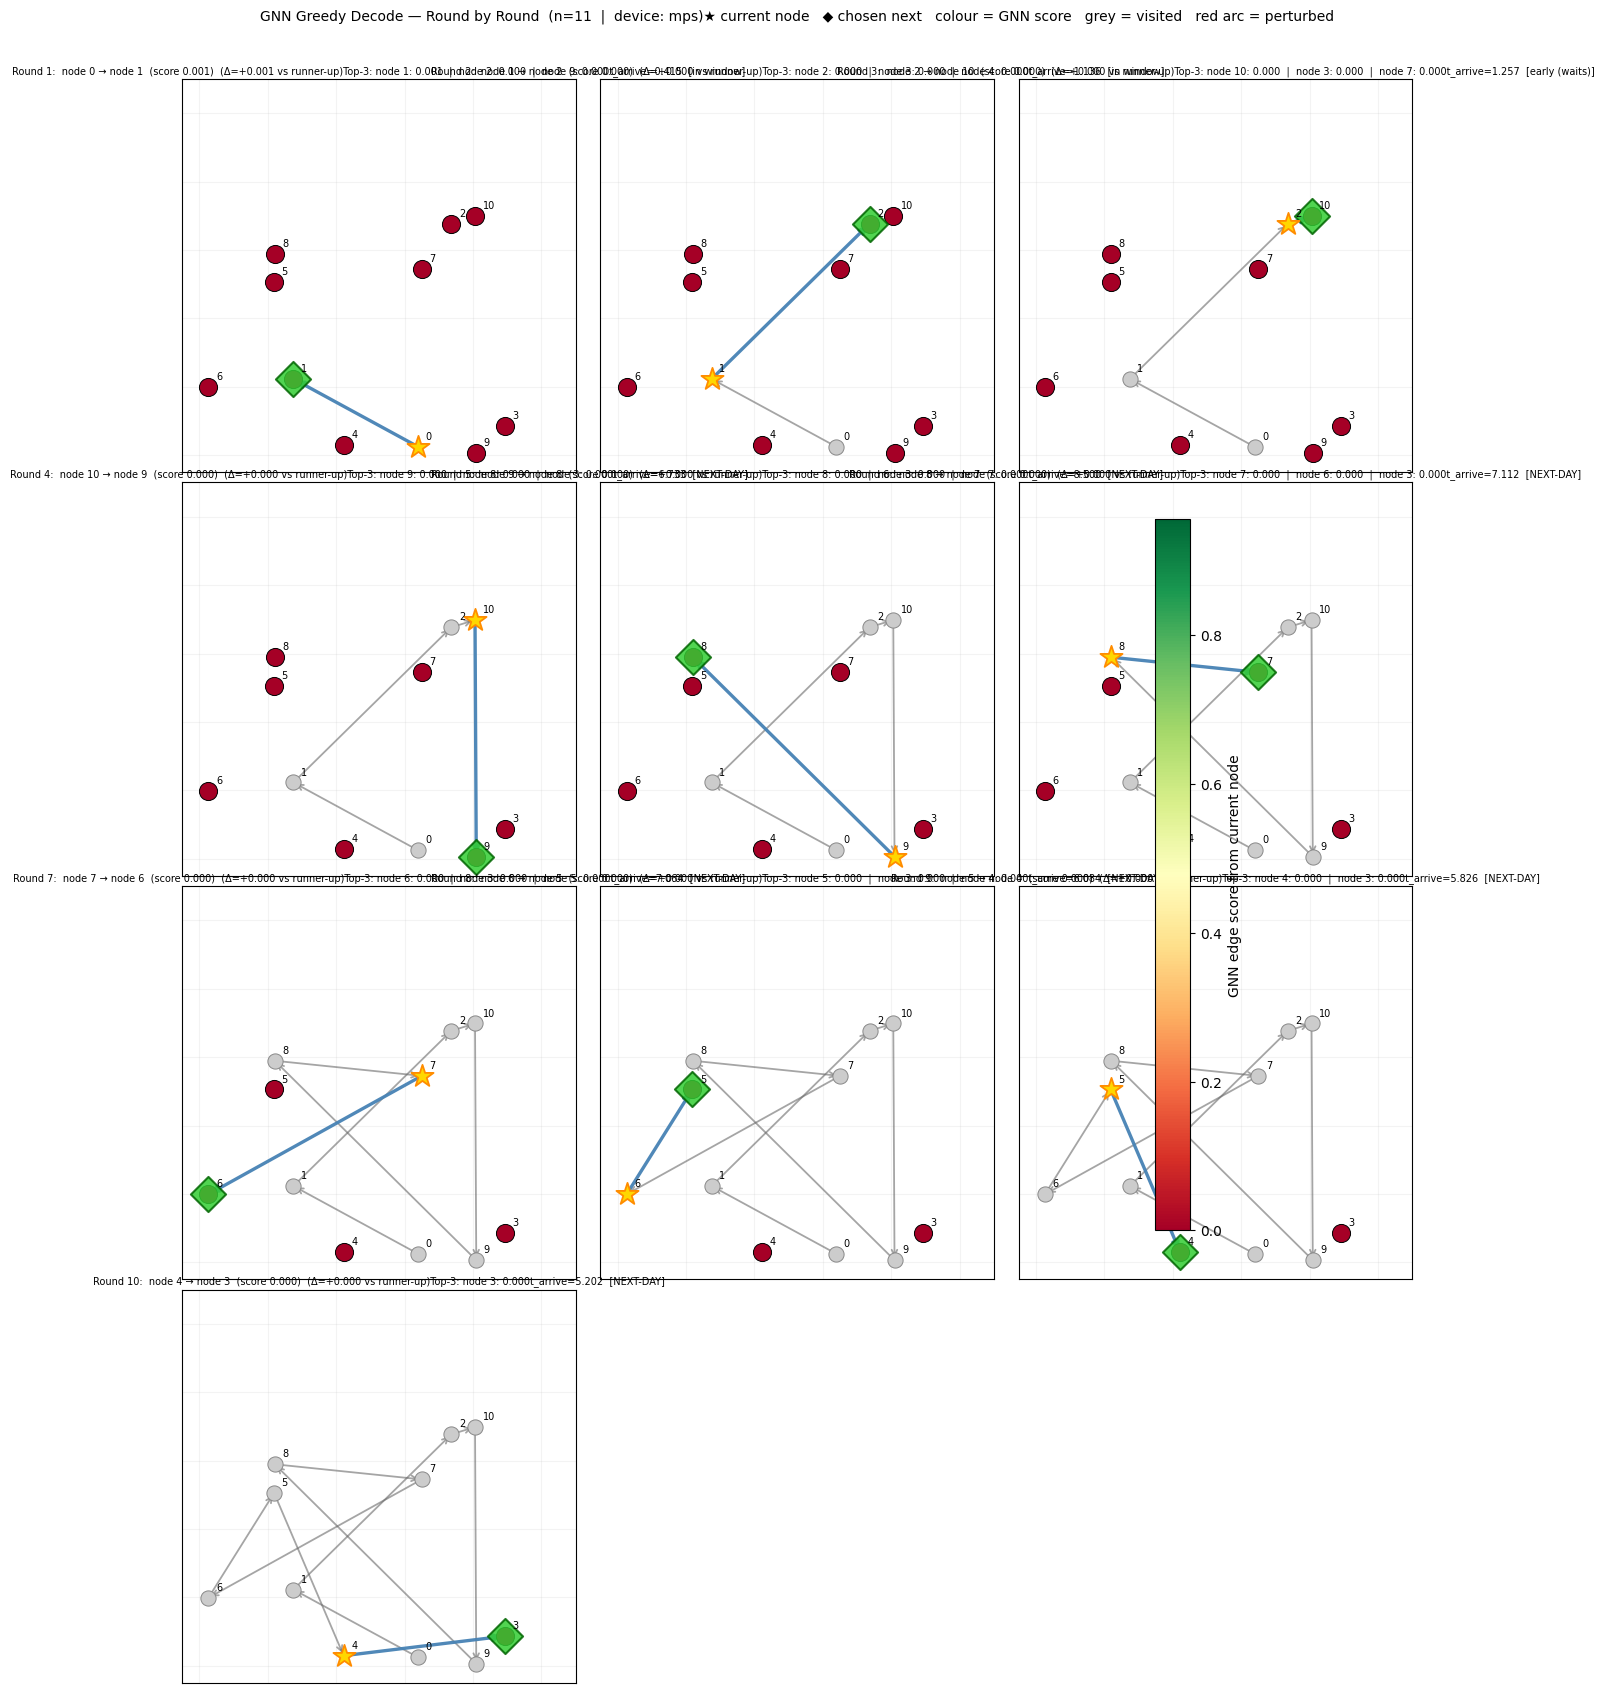

Final tour: [0, 1, 2, 10, 9, 8, 7, 6, 5, 4, 3]


In [29]:
# ── Step-by-step decode for the n=10 instance ────────────────────────────────
# max_rounds=None  → show all n-1 steps
# For larger n, use max_rounds=15 (or similar) to keep the figure manageable.
visualize_gnn_rounds(inst_10, model, max_rounds=None, cols=3)


In [30]:
# ── Larger instances: show the first 12 rounds ───────────────────────────────
# Uncomment whichever dataset you want to inspect.

# visualize_gnn_rounds(inst_50,  model, max_rounds=12, cols=4)
# visualize_gnn_rounds(inst_100, model, max_rounds=12, cols=4)
# visualize_gnn_rounds(inst_200, model, max_rounds=12, cols=4)
